# Take-home Task: Job-Posting NLP Pipeline

## Overview

Build an NLP pipeline that processes job-posting data to extract insights about roles, skills, and job-market patterns.

The task assesses practical experience with:

- Text preprocessing and cleaning
- Embeddings and semantic similarity
- Text classification
- Basic retrieval-augmented generation (RAG)
- Evaluation methodology

**Expected effort:** approximately **6–8 hours**.
We value clean, well-reasoned code over a polished product. Document your decisions and trade-offs.

---

## Data

**Source:** [LinkedIn Job Postings – Kaggle](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings)  
A pre-filtered sample of ~4,000 tech/data job postings is provided.

---

## Requirements

Complete the following four tasks in order. Each builds on the previous.

| Task | What | Deliverable |
|------|------|-------------|
| 1. Text preprocessing | Clean and prepare job descriptions for downstream NLP | Code + brief explanation of choices |
| 2. Role classification | Classify postings into role categories using the description text | Trained model + evaluation |
| 3. Embeddings & similarity | Embed job postings and implement semantic search | Working search function |
| 4. Evaluation & reflection | Assess quality and discuss limitations | Written analysis |

---

## 1. Text preprocessing

Clean and prepare the `description` field for downstream NLP tasks.

At minimum:

1. Explore the data: look at description length, missing values, duplicates, and any quality issues.
2. Implement a preprocessing pipeline that produces clean text suitable for embedding and classification.
3. Document your choices (what you removed, what you kept, and why).

Things to consider:
- HTML/markdown artefacts
- Boilerplate text (e.g. equal-opportunity statements)
- Very short or empty descriptions
- Duplicate content
- How preprocessing choices affect downstream tasks differently

---

## 2. Role classification

Build a classifier that predicts the **role category** of a job posting from its description text.

### Setup

The `role_category` column contains a pre-assigned label derived by keyword-matching on the `title` field:

| Category | Count |
|----------|------:|
| Software Engineer | 1,739 |
| Data Analyst | 890 |
| Data Scientist | 416 |
| DevOps / Cloud Engineer | 411 |
| Data Engineer | 401 |
| Machine Learning Engineer | 159 |
| Other | 56 |

Your classifier should predict `role_category` using only the `description` field (not the title).

### Task

1. Create train/test splits.
2. Train at least **two approaches** and compare them. For example:
   - TF-IDF + logistic regression (baseline)
   - Embedding-based classifier (e.g. embedding + simple NN, or fine-tuned model)
3. Evaluate with appropriate metrics (precision, recall, F1 — explain your choice of macro/micro/weighted).
4. Show a confusion matrix or per-class breakdown.
5. Discuss: which classes are hardest to distinguish and why?

---

## 3. Embeddings & similarity search

Create embeddings for the job postings and implement a semantic search function.

1. Choose an embedding model and justify your choice.
2. Embed the preprocessed job descriptions (or appropriate chunks).
3. Index them for efficient retrieval (e.g. FAISS, or brute-force cosine similarity for this dataset size).
4. Implement a search function that takes a natural-language query and returns the top-k most relevant postings.

Some suitable models from the `sentence-transformers` library:

- `all-MiniLM-L6-v2` — fast, lightweight (384 dims), good general-purpose baseline
- `all-mpnet-base-v2` — higher quality, larger (768 dims)
- `multi-qa-MiniLM-L6-cos-v1` — optimised for semantic search / question-answering

Pick one (or compare two) and explain your reasoning.

Demonstrate your search with at least **3 example queries**, e.g.:
- "machine learning engineer with NLP experience"
- "entry-level data analyst with SQL"
- "remote software engineer working on cloud infrastructure"

For each result, show the job title, company, and a short excerpt showing why it's relevant.

---

## 4. Evaluation & reflection

Write a brief section (in the notebook or a short markdown cell) covering:

1. **Classification errors:** Pick 2–3 misclassified examples from Task 2. Explain why the model likely got them wrong.
2. **Retrieval quality:** How would you measure whether your search returns relevant results? Propose a method (you don't need to fully implement it, but show your thinking).
3. **Limitations:** What are the main weaknesses of your pipeline? What would you improve with more time?

---

# Deliverables

Submit a GitHub repository or zipped project containing:

- This notebook (or equivalent scripts) with your solution;
- Dependency specification (`requirements.txt` or `pyproject.toml`);
- Reproducible setup instructions;
- Description of any API keys required.

---

# Notes

- A UI is not required.
- You may use any open-source libraries (scikit-learn, sentence-transformers, spaCy, etc.).
- If you use a pre-trained model, explain why you chose it.
- We care about your reasoning and methodology, not just the final numbers.
- If you run out of time, submit what you have with a note on what you'd do next.

---
## Data files

The following data files are provided in the `data/` directory:

| File | Rows | Description |
|------|-----:|-------------|
| `sample_postings.csv` | 4,072 | Job postings with title, description, company, location, salary, experience level, etc. |
| `sample_companies.csv` | 1,979 | Company profiles with name, description, size, location, and URL |
| `sample_skills.csv` | 6,800 | Skill tags linked to job postings (job_id → skill_abr) |
| `sample_skill_lookup.csv` | 35 | Skill abbreviation → full skill name mapping |
| `sample_industries.csv` | 422 | Industry labels (industry_id, industry_name) |

### Key columns

**sample_postings.csv:** `job_id`, `company_name`, `title`, `description`, `role_category`, `location`, `company_id`, `formatted_work_type`, `formatted_experience_level`, `skills_desc`, `max_salary`, `min_salary`, `remote_allowed`

**sample_companies.csv:** `company_id`, `name`, `description`, `company_size`, `state`, `country`, `city`, `url`

**sample_skills.csv:** `job_id`, `skill_abr`

**sample_skill_lookup.csv:** `skill_abr`, `skill_name` — maps abbreviations (e.g. `ENGR`) to full names (e.g. `Engineering`)

**sample_industries.csv:** `industry_id`, `industry_name`

---
## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("data")

# Load sample data
postings = pd.read_csv(DATA_DIR / "sample_postings.csv", low_memory=False)
print(f"Postings: {len(postings):,}")
print(f"Columns: {list(postings.columns)}")

Postings: 4,072
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'role_category']


In [2]:
# Load related tables
skills = pd.read_csv(DATA_DIR / "sample_skills.csv", low_memory=False) if (DATA_DIR / "sample_skills.csv").exists() else None
skill_lookup = pd.read_csv(DATA_DIR / "sample_skill_lookup.csv") if (DATA_DIR / "sample_skill_lookup.csv").exists() else None
companies = pd.read_csv(DATA_DIR / "sample_companies.csv", low_memory=False) if (DATA_DIR / "sample_companies.csv").exists() else None

if skills is not None:
    print(f"Skills entries: {len(skills):,}")
if skill_lookup is not None:
    print(f"Skill categories: {len(skill_lookup)}")
if companies is not None:
    print(f"Companies: {len(companies):,}")

Skills entries: 6,800
Skill categories: 35
Companies: 1,979


---
## Explore the data

In [3]:
postings.head(3)

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,role_category
0,133130219,NaN,Software Engineer,"Education Bachelor's degree in software, math,...",NaN,NaN,Los Angeles Metropolitan Area,NaN,1.0,NaN,...,1.713535e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN,Software Engineer
1,175485704,GOYT,Software Engineer,Job Description:GOYT is seeking a skilled and ...,NaN,NaN,"Denver, CO",76987056.0,273.0,NaN,...,1.713281e+12,NaN,0,PART_TIME,NaN,NaN,NaN,80202.0,8031.0,Software Engineer
2,2234533717,Ideando Inc,Full Stack Engineer,"Location: Remote\r\nCompany Overview:SkillFit,...",NaN,NaN,United States,69611476.0,21.0,NaN,...,1.713493e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN,Software Engineer


In [4]:
# Role distribution
postings["title"].value_counts().head(20)

title
Software Engineer                   181
Senior Software Engineer            164
Data Analyst                        137
Data Engineer                        91
Full Stack Engineer                  58
DevOps Engineer                      57
Data Scientist                       56
Senior Data Engineer                 44
Cloud Engineer                       32
Embedded Software Engineer           30
Senior Data Analyst                  25
Machine Learning Engineer            23
Principal Software Engineer          21
Senior Data Scientist                21
Lead Software Engineer               20
Online Data Analyst                  20
Software Engineer in Test            20
Staff Software Engineer              19
Senior Machine Learning Engineer     19
Java Software Engineer               16
Name: count, dtype: int64

In [5]:
# Check description field
print(f"Postings with description: {postings['description'].notna().sum():,}")
print(f"\nSample description (first 500 chars):")
print(postings['description'].dropna().iloc[0][:500])

Postings with description: 4,072

Sample description (first 500 chars):
Education Bachelor's degree in software, math, or science required Job Skills Analytical skills, group work, knowledge of intended audience, understanding of different roles


---
## Your work starts here

Use the cells above as a starting point. Add new cells below to build your solution.

In [6]:
# Other imports

import matplotlib.pyplot as plt
from IPython.display import display # ensure display() is available
import unicodedata
import re

## 01. Data overview

Before looking at the job descriptions, I first checked the provided files, the main modelling table, and the relationships between datasets.

Each row in `sample_postings.csv` represents one job posting. The related company and skill tables are useful for understanding the data, but they are not treated as model features at this stage.

In [7]:
industries = pd.read_csv(DATA_DIR / "sample_industries.csv")

datasets = {
    "Postings": postings,
    "Companies": companies,
    "Skills": skills,
    "Skill lookup": skill_lookup,
    "Industries": industries,
}

dataset_summary = pd.DataFrame(
    {
        "rows": {name: len(data) for name, data in datasets.items()},
        "columns": {name: data.shape[1] for name, data in datasets.items()},
    }
)

dataset_summary

,rows,columns
Postings,4072,32
Companies,1979,10
Skills,6800,2
Skill lookup,35,2
Industries,422,2


In [8]:
main_columns = [
    "job_id",
    "title",
    "description",
    "role_category",
    "company_id",
    "company_name",
]

postings_summary = pd.DataFrame(
    {
        "dtype": postings[main_columns].dtypes.astype(str),
        "missing": postings[main_columns].isna().sum(),
        "unique": postings[main_columns].nunique(),
    }
)

postings_summary

,dtype,missing,unique
job_id,int64,0,4072
title,str,0,2326
description,str,0,3628
role_category,str,0,7
company_id,float64,37,1979
company_name,str,37,1975


In [9]:
relationship_checks = pd.Series(
    {
        "Posting IDs are unique": postings["job_id"].is_unique,
        "Company IDs are unique": companies["company_id"].is_unique,
        "Skill lookup codes are unique": skill_lookup["skill_abr"].is_unique,
        "Skill rows without a matching posting": (
            ~skills["job_id"].isin(postings["job_id"])
        ).sum(),
        "Postings without skill records": (
            ~postings["job_id"].isin(skills["job_id"])
        ).sum(),
        "Postings with an unmatched company ID": (
            postings["company_id"].notna()
            & ~postings["company_id"].isin(companies["company_id"])
        ).sum(),
        "Skill codes without a lookup value": (
            ~skills["skill_abr"].isin(skill_lookup["skill_abr"])
        ).sum(),
    },
    name="result",
)

relationship_checks.to_frame()

,result
Posting IDs are unique,True
Company IDs are unique,True
Skill lookup codes are unique,True
Skill rows without a matching posting,0
Postings without skill records,131
Postings with an unmatched company ID,0
Skill codes without a lookup value,0


### Initial observations

The postings table contains 4072 rows, all with unique job_id.

The target contains seven categories, and every posting has at least a title, description and target label.

We can also notice there are fewer unique descriptions than postings, indicating there are **some duplicate descriptions** that will need to be investigated.

Besides that, we can see the company and skills relationships are mostly complete (all available company IDs and skill codes have matching records). However, there are 37 postings without company info and 131 without skill records.

## 02. Target distribution

The target classes were derived from job titles (weak supervision) so they should be treated as weak labels rather than perfect ground truth. 

Let's first check their size and balance, as this will affect the later splitting strategy and the choice of evaluation metrics.

role_category,count,proportion
Software Engineer,1739,42.7%
Data Analyst,890,21.9%
Data Scientist,416,10.2%
DevOps / Cloud Engineer,411,10.1%
Data Engineer,401,9.8%
Machine Learning Engineer,159,3.9%
Other,56,1.4%


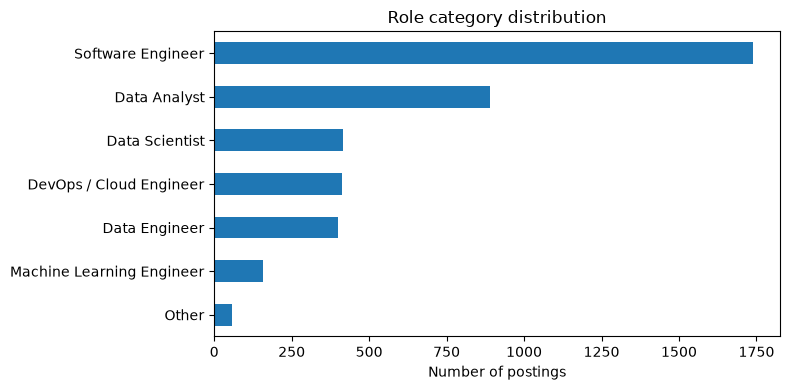

In [10]:
role_distribution = (
    postings["role_category"]
    .value_counts()
    .rename_axis("role_category")
    .reset_index(name="count")
)

role_distribution["proportion"] = (
    role_distribution["count"] / len(postings)
)

display(
    role_distribution.style
    .format({"proportion": "{:.1%}"})
    .hide(axis="index")
)

ax = role_distribution.plot.barh(
    x="role_category",
    y="count",
    legend=False,
    figsize=(8, 4),
)

ax.set_title("Role category distribution")
ax.set_xlabel("Number of postings")
ax.set_ylabel("")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

The dataset is clearly imbalanced. `Software Engineer` represents 42.7% of the postings, while `Machine Learning Engineer` represents 3.9% and `Other` only 1.4%.

This means accuracy alone could hide poor performance on the smaller categories. So **stratification** (preserving approx. the same proportion in every subset) and **class-sensitive metrics** (such as macro F1) will be important, as they **help account for class imbalance** during splitting and evaluation.

### Evaluation 

The idea for the evaluation design is to use 80% of the data for development (train + validation) and keep 20% as an untouched final test set. 

Within the development data, I intend to use 5-fold stratified cross-validation. The goal of it is to have a more reliable model comparison over having a fixed train/validation/test split.

Before creating the split, let's estimate how many examples each class would contribute.

In [11]:
split_feasibility = role_distribution[
    ["role_category", "count"]
].copy()

split_feasibility["approx_development_rows"] = (
    split_feasibility["count"] * 0.8
).round().astype(int)

split_feasibility["approx_test_rows"] = (
    split_feasibility["count"] * 0.2
).round().astype(int)

split_feasibility["approx_validation_rows_per_fold"] = (
    split_feasibility["approx_development_rows"] / 5
).round().astype(int)

display(
    split_feasibility.style.hide(axis="index")
)

role_category,count,approx_development_rows,approx_test_rows,approx_validation_rows_per_fold
Software Engineer,1739,1391,348,278
Data Analyst,890,712,178,142
Data Scientist,416,333,83,67
DevOps / Cloud Engineer,411,329,82,66
Data Engineer,401,321,80,64
Machine Learning Engineer,159,127,32,25
Other,56,45,11,9


From the class counts alone, a stratified 80/20 split and 5-fold cross-validation validation appear possible.

However, the `Other` category would contribute only about 11 test examples and 9 validation examples per fold. This raises a need to interpret its metrics carefully as they may vary considerably between folds.

This conclusion _remains provisional_ because the duplicate analysis may later show that related postings need to remain in the same split.

## 03. Description availability and length

Before deciding how to clean the descriptions, let's check whether they are usable and how much their length varies.

At this point, the goal is only to understand the data. No descriptions will be removed and no minimum length will be chosen yet.

In [12]:
description_audit = postings[
    ["job_id", "title", "role_category", "description"]
].copy()

description_audit["char_count"] = (
    description_audit["description"].str.len()
)

description_audit["word_count"] = (
    description_audit["description"].str.split().str.len()
)

# Create a compact description preview version for displaying examples.
description_audit["description_preview"] = (
    description_audit["description"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 250)
)

description_quality = pd.Series(
    {
        "Missing descriptions": postings["description"].isna().sum(),
        "Non-string descriptions": (
            postings["description"].notna()
            & ~postings["description"].map(
                lambda value: isinstance(value, str)
            )
        ).sum(),
        "Empty or whitespace-only descriptions": (
            postings["description"].map(
                lambda value: isinstance(value, str)
                and not value.strip()
            )
        ).sum(),
    },
    name="count",
)

display(description_quality.to_frame())

length_summary = (
    description_audit[["char_count", "word_count"]]
    .quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1])
    .rename_axis("quantile")
)

display(length_summary)

,count
Missing descriptions,0
Non-string descriptions,0
Empty or whitespace-only descriptions,0


,char_count,word_count
quantile,,
0.00,41.00,1.00
0.01,304.81,40.00
0.05,685.55,94.00
0.25,1898.75,253.00
0.50,3641.00,488.50
0.75,5423.50,755.00
0.95,7868.00,1113.00
0.99,9722.92,1350.29
1.00,17868.00,2486.00


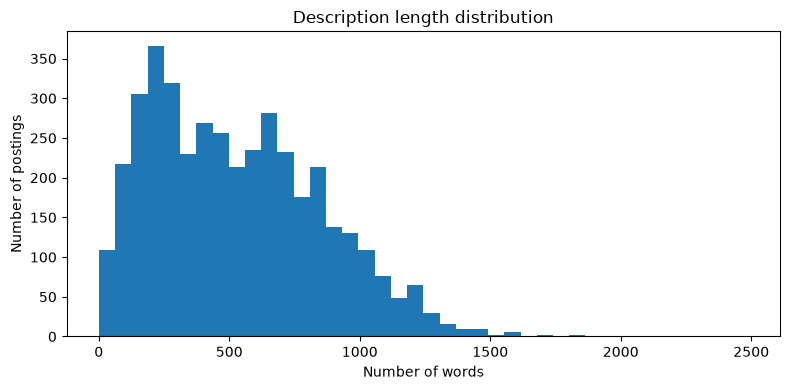

title,role_category,char_count,word_count,description_preview
Senior Software Engineer,Software Engineer,47,1,https://boomi.com/boomi-jobs/?gh_jid=5149123004
Data Analyst or Data Product Manager (Native US Citizens Only),Data Analyst,41,4,Skill Sets: SparkPyspark.TableauSQL Query
Software Engineer,Software Engineer,100,11,Cryptography developer for digital cash cryptosystem. Universal crypto transactions in milliseconds.
Senior Data Analyst,Data Analyst,107,16,"Must have : Data Analyst: with Big Query, and SQL.Must Have Skills:2 intermediate analytics skills (BQ/SQL)"
Software Engineer in Test,Software Engineer,98,19,"Must be local and ex-AMEX only Must be strong in React, Java, Selenium, and BDD Any visa is fine"
Data Engineer,Data Engineer,150,21,SQL (expert)Snowflake - not a roadblock (added advantage)Cloud - AWS is preferred (exp on any cloud)Python – intermediateDatabricks - added advantage.
Full Stack Engineer,Software Engineer,248,21,Javascript/TypescriptNode.jsVueJS/React/Angular or similarAWS experienceCI/CD a plusWorkDay/eTime experience is a huge plusJavascript/TypescriptNode.jsVueJS/React/Angular or similarAWS experienceCI/CD a plusWorkDay/eTime experience is a huge plus
Java full stack developer with react - W2,Software Engineer,169,21,"immediate hiring for H1T, W2 Title: Java Full Stack with React expLocation: Dallas, TX (only locals) Regards and ThanksCrystalLead IT RecruiterCrystal@americanunit.com"
Software Engineer,Software Engineer,173,23,"Education Bachelor's degree in software, math, or science required Job Skills Analytical skills, group work, knowledge of intended audience, understanding of different roles"
Embedded Software Engineer,Software Engineer,218,23,"Embedded Software Engineer Location: Spring, TX – Onsite RoleDuration: Long Term ProjectSkills:Embedded SoftwareScripting like c, PythonCommon Protocols – iSCSI, UART, SPIMicro controllerARMAnalysersFW DevelopmentUEFI"


In [13]:
ax = description_audit["word_count"].plot.hist(
    bins=40,
    figsize=(8, 4),
)

ax.set_title("Description length distribution")
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of postings")

plt.tight_layout()
plt.show()

# Look through the shortest descriptions (fewer word counts)
shortest_descriptions = (
    description_audit
    .drop_duplicates("description")
    .nsmallest(10, "word_count")
)

display(
    shortest_descriptions[
        [
            "title",
            "role_category",
            "char_count",
            "word_count",
            "description_preview",
        ]
    ].style.hide(axis="index")
)

In [14]:
# Check whether any description contains only a URL.
url_only_mask = (
    postings["description"]
    .str.strip()
    .str.fullmatch(
        r"(?:https?://|www\.)\S+",
        case=False,
        na=False,
    )
)

url_only_descriptions = postings.loc[
    url_only_mask,
    [
        "job_id",
        "title",
        "role_category",
        "description",
    ],
]

print(
    f"URL-only descriptions: "
    f"{len(url_only_descriptions)}"
)

display(
    url_only_descriptions.style.hide(axis="index")
)

URL-only descriptions: 1


job_id,title,role_category,description
3884839409,Senior Software Engineer,Software Engineer,https://boomi.com/boomi-jobs/?gh_jid=5149123004


**All postings** contain a **non-empty description**, but **their length varies considerably**.

The median description has around 489 words, while 5% have fewer than 94 words. There is also a long upper tail, with the longest description reaching almost 2,500 words.

One record contains only a URL and does not provide usable description text for the classifier, so it should be excluded during data preparation. The other short descriptions still contain potentially useful technical information.

Apart from the URL-only case, length alone does not provide a defensible cutoff for removing records.

## 04. Text formatting

Job descriptions often contain HTML, links and copied formatting. Before deciding what should be cleaned, let's check which of these patterns are actually present in this dataset.

In [15]:
format_patterns = {
    # Matches common opening and closing HTML tags:
    # </? allows either "<tag>" or "</tag>",
    # [A-Za-z] requires the tag name to begin with a letter,
    # and [^>]* matches the rest of the tag until ">".
    "HTML tags": r"</?[A-Za-z][^>]*>",
    
    # Matches the main forms of HTML entities:
    # named entities such as &amp;,
    # decimal codes such as &#39;,
    # and hexadecimal codes such as &#x27;.
    "HTML entities": r"&(?:[a-zA-Z]+|#\d+|#x[0-9a-fA-F]+);",
    
    # Links beginning with http, https or www.
    "URLs": r"(?:https?://|www\.)\S+",
    
    # Explicit new-line characters like '\n' or '\r'.
    "Line breaks": r"[\r\n]",
    
    # Matches two or more consecutive spaces or tab characters.
    "Repeated spaces or tabs": r"[ \t]{2,}",
    
    # (?m) makes ^ check the start of every line.
    # The rest matches headings such as "# Title" or "### Requirements".
    "Markdown-like headings": r"(?m)^\s*#{1,6}\s+\S",
    
    # Matches lines beginning with "-", "*" or "•",
    # followed by some text.
    "Markdown-like bullets": r"(?m)^\s*[-*•]\s+\S",
    
    # Matches ASCII control-character ranges, excluding normal
    # tabs and line breaks, plus common Unicode zero-width characters.
    "Invisible or control characters": (
        r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F-\x9F"
        r"\u200B\u200C\u200D\u2060\uFEFF]"
    ),
}

format_summary = pd.DataFrame(
    {
        "count": {
            issue: postings["description"]
            .str.contains(pattern, regex=True)
            .sum()
            for issue, pattern in format_patterns.items()
        }
    }
)

format_summary["proportion"] = (
    format_summary["count"] / len(postings)
)

display(
    format_summary.style.format(
        {"proportion": "{:.1%}"}
    )
)

,count,proportion
HTML tags,0,0.0%
HTML entities,5,0.1%
URLs,651,16.0%
Line breaks,3829,94.0%
Repeated spaces or tabs,712,17.5%
Markdown-like headings,3,0.1%
Markdown-like bullets,104,2.6%
Invisible or control characters,38,0.9%


There are **no HTML tags** in the descriptions, while **HTML entities and Markdown-like formatting are very rare**.

**Line breaks appear in almost every description**, so they seem to be part of the normal job-posting structure rather than an issue by themselves.

**URLs and repeated spacing are more common**. Before deciding whether either should be cleaned, I will inspect a few examples and check what information they contain. The invisible or control characters also need a closer look, as they are not visible in a normal text preview.

In [16]:
patterns_to_inspect = [
    "HTML entities",
    "URLs",
    "Repeated spaces or tabs",
]

# Helper to show text preview around the matched text
def extract_match_context(text, pattern, context_chars=120):
    match = re.search(pattern, text)

    start = max(0, match.start() - context_chars)
    end = min(len(text), match.end() + context_chars)

    context = re.sub(r"\s+", " ", text[start:end]).strip()

    prefix = "..." if start > 0 else ""
    suffix = "..." if end < len(text) else ""

    return f"{prefix}{context}{suffix}"

for issue in patterns_to_inspect:
    pattern = format_patterns[issue]

    matches = postings.loc[
        postings["description"].str.contains(pattern, regex=True),
        ["title", "role_category", "description"],
    ].head(3).copy()

    matches["matched_text"] = (
        matches["description"]
        .str.extract(f"({pattern})", expand=False)
        .map(repr)
    )

    matches["match_context"] = (
        matches["description"]
        .map(lambda text: extract_match_context(text, pattern))
    )

    print(issue)

    display(
        matches[
            [
                "title",
                "role_category",
                "matched_text",
                "match_context",
            ]
        ]
        .style
        .hide(axis="index")
        .format(escape="html")
    )

HTML entities


title,role_category,matched_text,match_context
Office/Administration - Data Analyst Lv3 #: 24-02340,Data Analyst,'&plus;',"...ormation technology, computer science, data and analytics, business administration or related study. Experience 4&plus; years of experience in data Experience in implementing and/or working within a Data Governance committee and/or framewo..."
Software Engineer,Software Engineer,'&#39;',"...nts, and/or new software systems and applications.Drives development of components through own and subordinate engineers&#39; work.Develops technical solutions that meet specifications and that impact future developments.Executes assigned compon..."
"Vice President, Finance – Data Science & Visualization Analytics",Data Scientist,'&L;',...g to: collaborate with BU LFO teams on strategic business questions; support the EFP&A team in managing the Enterprise P&L; and share trends / insights with IR for potential external messagingContinue evolution from execution-oriented to an in...


URLs


title,role_category,matched_text,match_context
Full Stack Engineer,Software Engineer,'https://skillfitai.com/',"...alent acquisition industry with innovative technology solutions. We highly encourage you to explore our beta product at https://skillfitai.com/ before submitting your application, allowing you to gain a deeper understanding of our mission and objectives. Become a..."
Senior Software Engineer,Software Engineer,'https://usestyle.ai/We',"...ch as scope and responsibilities, the candidate’s experience and qualifications, and onboarding. Useful links:Website: https://usestyle.ai/We practice our tenets religiously: https://usestyle.ai/tenetsLearn more about our company culture here: https://usestylea..."
Staff Software Engineer (AHT),Software Engineer,'http://www.northropgrumman.com/EEO',"...status, disability, or any other protected class. For our complete EEO/AA and Pay Transparency statement, please visit http://www.northropgrumman.com/EEO . U.S. Citizenship is required for all positions with a government clearance and certain other restricted positions...."


Repeated spaces or tabs


title,role_category,matched_text,match_context
Data Science Software Engineer,Data Scientist,' ',"...cluding 100% employer sponsored medical, dental and vision insurance, and flexible working hours. Position Overview Sovrinti is looking for an experienced software engineer at our Westborough, MA head office. We are looking for a candid..."
Full Stack Engineer,Software Engineer,' ',"...deal candidate need to have hands on experience with the Node.Js stack. The main responsibilities in this role includes: ResponsibilitiesFull Stack Development with JS, Node.JSMaintain and monitor server-side web applications with Node.js an..."
"Senior Analyst, Data & Analytics",Data Analyst,' ',...yst will collaborate with multidisciplinary teams in a fast-paced environment to deliver analytics solutions to clients. Core Accountabilities:4-5+ years professional experience 2+ years working in a client-focused environment such as an ad...


In [17]:
invisible_matches = (
    postings["description"]
    .str.findall(format_patterns["Invisible or control characters"])
    .explode()
    .dropna()
)

invisible_character_summary = (
    invisible_matches
    .value_counts()
    .rename_axis("character")
    .reset_index(name="occurrences")
)

invisible_character_summary["unicode_code"] = (
    invisible_character_summary["character"]
    .map(lambda character: f"U+{ord(character):04X}")
)

invisible_character_summary["character_name"] = (
    invisible_character_summary["character"]
    .map(
        lambda character: unicodedata.name(
            character,
            "Unnamed control character",
        )
    )
)

print("Invisible or control characters\n")
display(
    invisible_character_summary[
        ["unicode_code", "character_name", "occurrences"]
    ].style.hide(axis="index")
)

Invisible or control characters



unicode_code,character_name,occurrences
U+FEFF,ZERO WIDTH NO-BREAK SPACE,56
U+200D,ZERO WIDTH JOINER,14
U+0080,Unnamed control character,6
U+0099,Unnamed control character,6


In [18]:
# Representative technical terms whose punctuation carries meaning.
# This is a spot check rather than a complete technology inventory.
technical_terms = [
    "C++", # +
    "C#",  # #
    ".NET", # dot
    "Node.js", # dot
    "CI/CD", # slash
    "ETL/ELT", # slash
    "A/B", # slash
    "scikit-learn",  # hyphen
    "R&D",  # &
]

technical_term_summary = pd.DataFrame(
    {
        "count": {
            term: postings["description"]
            .str.contains(term, case=False, regex=False)
            .sum()
            for term in technical_terms
        }
    }
)

technical_term_summary

,count
C++,511
C#,413
.NET,294
Node.js,214
CI/CD,582
ETL/ELT,40
A/B,114
scikit-learn,77
R&D,69


- Most descriptions use line breaks, as expected from long postings.

- There is no HTML to remove, and HTML entities or Markdown formatting are very rare. URLs and repeated spacing are more common, but the examples show that they can appear in different contexts.

- Most of the matched invisible characters are zero-width no-break spaces. There are also some zero-width joiners and unnamed control characters, so they should be handled carefully during preprocessing rather than removed blindly.

- The technical-term check also confirms that punctuation is often meaningful. Terms such as `C++`, `C#`, `.NET`, `CI/CD` and `Node.js` appear frequently, so broad punctuation removal would risk damaging useful information.

## 05. Exact duplicates

As mentioned before, there are fewer unique descriptions than postings, so some descriptions appear more than once.

Before deciding whether these are duplicates that should be removed, I want to understand how many postings are affected, how large the repeated groups are, and whether they share the same labels, titles and companies.

In [19]:
# Count how many times each exact description appears.
description_counts = (
    postings["description"]
    .value_counts()
    .rename("group_size")
)

# Keep only descriptions that appear more than once.
duplicate_description_counts = description_counts[
    description_counts > 1
]

duplicate_summary = pd.DataFrame(
    {
        "metric": [
            "Duplicate description groups",
            "Postings in duplicate groups",
            "Rows removed if keeping one row per description + label",
            "Largest duplicate group",
        ],
        "value": [
            len(duplicate_description_counts),
            duplicate_description_counts.sum(),
            postings.duplicated(
                subset=["description", "role_category"]
            ).sum(),
            duplicate_description_counts.max(),
        ],
    }
)

display(duplicate_summary.style.hide(axis="index"))

duplicate_share = (
    duplicate_description_counts.sum() / len(postings)
)

print(
    f"{duplicate_share:.1%} of postings belong to an exact duplicate group.\n"
)

# Show how many duplicate groups have each group size.
duplicate_group_sizes = (
    duplicate_description_counts
    .value_counts()
    .sort_index()
    .rename_axis("postings_per_group")
    .reset_index(name="number_of_groups")
)

display(
    duplicate_group_sizes.style.hide(axis="index")
)

metric,value
Duplicate description groups,196
Postings in duplicate groups,640
Rows removed if keeping one row per description + label,442
Largest duplicate group,34


15.7% of postings belong to an exact duplicate group.



postings_per_group,number_of_groups
2,112
3,35
4,32
5,4
6,4
7,2
8,1
9,1
11,1
14,1


### What changes across duplicate postings?

The same description may be reposted under a different title or company. More importantly, it may also receive a different target label.

I compared each duplicate group across these three fields.

In [20]:
# Add the size of each description group to the original postings.
duplicate_postings = (
    postings[
        [
            "job_id",
            "title",
            "role_category",
            "company_id",
            "company_name",
            "description",
        ]
    ]
    .assign(
        group_size=lambda data: (
            data.groupby("description")["job_id"].transform("size")
        )
    )
    .query("group_size > 1")
)

# Create one row per repeated description and count how many
# different labels, titles and companies appear in each group.
duplicate_groups = (
    duplicate_postings
    .groupby("description")
    .agg(
        group_size=("job_id", "size"),
        role_categories=("role_category", "nunique"),
        titles=("title", "nunique"),
        companies=("company_id", "nunique"),
    )
    .reset_index()
)

# Compare how many groups stay consistent or change for each field.
duplicate_consistency = pd.DataFrame(
    {
        "field": [
            "Role category",
            "Job title",
            "Company",
        ],
        "same_across_group": [
            (duplicate_groups["role_categories"] == 1).sum(),
            (duplicate_groups["titles"] == 1).sum(),
            (duplicate_groups["companies"] == 1).sum(),
        ],
        "different_across_group": [
            (duplicate_groups["role_categories"] > 1).sum(),
            (duplicate_groups["titles"] > 1).sum(),
            (duplicate_groups["companies"] > 1).sum(),
        ],
    }
)

display(
    duplicate_consistency.style.hide(axis="index")
)

field,same_across_group,different_across_group
Role category,194,2
Job title,154,42
Company,190,6


### Largest duplicate groups

The counts above show how often fields change, but not what the duplicate groups actually represent.

I inspected the largest groups to see whether they look like repeated postings, reused company templates or descriptions shared across different roles.

In [21]:
# Keep the displayed values short when a group contains many
# different titles, labels or companies.
def summarize_unique(values, max_values=3):
    unique_values = pd.unique(values.dropna())

    summary = " | ".join(
        map(str, unique_values[:max_values])
    )

    if len(unique_values) > max_values:
        summary = f"{summary} | ..."

    return summary


largest_duplicate_groups = (
    duplicate_postings
    .groupby("description")
    .agg(
        postings=("job_id", "size"),
        labels=("role_category", summarize_unique),
        unique_titles=("title", "nunique"),
        title_examples=("title", summarize_unique),
        unique_companies=("company_id", "nunique"),
        company_examples=("company_name", summarize_unique),
    )
    .sort_values("postings", ascending=False)
    .head(6)
    .reset_index()
)

largest_duplicate_groups["description_preview"] = (
    largest_duplicate_groups["description"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 180)
)

display(
    largest_duplicate_groups[
        [
            "postings",
            "labels",
            "unique_titles",
            "title_examples",
            "unique_companies",
            "company_examples",
            "description_preview",
        ]
    ].style.hide(axis="index")
)

postings,labels,unique_titles,title_examples,unique_companies,company_examples,description_preview
34,Data Analyst,1,Data Analyst,1,DataAnnotation,DataAnnotation is committed to creating quality AI. Join our team to help train AI chatbots while gaining the flexibility of remote work and choosing your own schedule. We are look
31,Software Engineer,1,Software Engineer,1,DataAnnotation,DataAnnotation is committed to creating quality AI. Join our team to help train AI chatbots while gaining the flexibility of remote work and choosing your own schedule. We are look
18,Data Analyst,6,Data Analyst-VA | Data Analyst-WA | Data Analyst-IL | ...,1,ATC,Job Title: Entry Level Business Analyst / Product Owner U.S. Citizens and those authorized to work in the U.S. are encouraged to apply. We are able to sponsor at this time.We are a
14,Data Scientist | Data Analyst,11,NLP/data science/Data Analysis(Intern apr 30) | Data Science/NLP intern ( Apr 30) | Data Analyst/Data Science/NLP (Intern apr 30) DIN01 | ...,2,Data Glacier | Coders Data,The ideal candidate will use their passion for big data and analytics to provide insights to the business covering a range of topics. They will be responsible for conducting both r
11,Data Analyst,1,Online Data Analyst,1,TELUS International,"We are hiring freelance English speaking Online Data Analysts for a project aimed at improving the content and quality of digital maps, which are used by millions of users globally"
9,Data Analyst,1,Online Data Analyst,1,TELUS International AI Data Solutions,TELUS International AI-Data Solutions partners with a diverse and vibrant community to help our customers enhance their AI and machine learning models. The work of our AI Community


### Conflicting labels

Only two exact-description groups contain more than one target label, so I inspected both of them rather than taking a sample.

These cases are especially important because the classifier would receive exactly the same input text with different expected outputs.

In [22]:
conflicting_descriptions = duplicate_groups.loc[
    duplicate_groups["role_categories"] > 1,
    "description",
]

for group_number, description in enumerate(
    conflicting_descriptions,
    start=1,
):
    group = (
        duplicate_postings.loc[
            duplicate_postings["description"].eq(description),
            [
                "job_id",
                "title",
                "role_category",
                "company_name",
            ],
        ]
        .sort_values(["role_category", "title"])
    )

    # Show the shared description once instead of repeating it
    # for every posting in the group.
    description_preview = " ".join(description.split())

    # if len(description_preview) > 300:
    #     description_preview = (
    #         f"{description_preview[:]}..."
    #     )

    print(
        f"Conflicting group {group_number}: "
        f"{len(group)} postings"
    )
    print(
        f"Description preview: "
        f"{description_preview}\n"
    )

    display(
        group.style.hide(axis="index")
    )

Conflicting group 1: 14 postings
Description preview: The ideal candidate will use their passion for big data and analytics to provide insights to the business covering a range of topics. They will be responsible for conducting both recurring and ad hoc analysis for business users. ResponsibilitiesUnderstand the day-to-day issues that our business faces, which can be better understood with data Compile and analyze data related to business' issues Develop clear visualizations to convey complicated data in a straightforward fashion QualificationsBachelor's or Master's degree in Statistics or Applied Mathematics or equivalent experience 1 - 2 years' Data Analysis experience Proficient in SQL



job_id,title,role_category,company_name
3895242027,Data Analyst,Data Analyst,Coders Data
3901457333,Data Analyst,Data Analyst,Coders Data
3901461025,Data Analyst,Data Analyst,Coders Data
3904389545,Data Analyst,Data Analyst,Coders Data
3885109955,Data Analyst/Data Science/NLP (Intern apr 30) DIN01,Data Scientist,Data Glacier
3890895123,Data Science Intern DIN17,Data Scientist,Data Glacier
3891075442,Data Science Intern DIN18,Data Scientist,Data Glacier
3891278079,Data Science Intern DIN19,Data Scientist,Data Glacier
3885110673,Data Science intern ( Apr 30) -DIN01,Data Scientist,Data Glacier
3891070831,Data Science intern -DIN17,Data Scientist,Data Glacier


Conflicting group 2: 3 postings
Description preview: hackajob transforms your job search into a personalized experience, where you're in control. We align your skills, salary expectations, and location preferences to deliver tailored opportunities. Experience the power of being matched to IT roles across various industries throughout the United States, ensuring your career journey is uniquely yours. We have plenty of opportunities at the moment for AI/ML Engineer/Data Scientist preferred experience within industries such as defense, intelligence, aerospace, government contracting, and related fields. The AI/ML Engineer/Data Scientist will be responsible for developing algorithms, scripting, building predictive analytics, automating processes, and applying machine learning techniques. They will utilize a variety of tools and frameworks to transform data into actionable insights that aid senior leadership in making informed decisions. Working closely with customer management, project man

job_id,title,role_category,company_name
3905875652,Data Scientist,Data Scientist,hackajob
3905875688,Data Scientist,Data Scientist,hackajob
3905881936,Machine Learning Engineer,Machine Learning Engineer,hackajob


Most exact duplicate groups are consistent: 194 out of 196 contain only one role category.

Many also look like reposts or reused templates. In 42 groups, the same description appears under different titles, while only 6 groups span multiple companies.

The two conflicting groups do not necessarily contain incorrect labels. Their descriptions are broad enough to fit more than one related role, which means the expected category cannot always be determined from the description alone.

**Decision for the later modelling step:**

- Keep one row per unique `description` and `role_category` combination, so repeated postings do not receive extra weight.
- Keep cases where the same description has different labels, as they reflect a real limitation of the task.
- Keep all rows sharing the same description in the same dataset split, to prevent identical text from appearing in both development and test data.

These decisions will be applied later, once the text preparation and dataset split are defined.

## Data audit summary

The descriptions are generally usable, but the dataset has two important constraints: a strong class imbalance and a material number of exact duplicates. One URL-only record should be excluded, but description length otherwise does not support a general removal threshold.

Based on the findings above, I will:

* apply conservative cleaning focused on the formatting issues observed in the data, while preserving meaningful technical punctuation;
* keep one row per unique `description` and `role_category` combination;
* keep identical descriptions in the same dataset split;
* preserve class proportions where possible and use macro F1 as the main model-selection metric.

Lightly edited reposts, shared boilerplate and broader weak-label ambiguity remain possible limitations, but a more advanced investigation is unlikely to improve the decisions needed for this assignment.


## 06. Preparing the modelling data

From the audit, we figured out we should do the following cleaning steps:

* decode the few HTML entities;
* fix the one broken apostrophe pattern found;
* replace URLs inside otherwise useful descriptions with `[URL]`;
* replace the invisible characters found in the audit with spaces;
* turn line breaks, tabs and repeated whitespace into single spaces.

I am keeping the cleaning conservative because the descriptions are already mostly usable. Case and punctuation are left unchanged so terms such as `C++`, `C#`, `.NET`, `CI/CD` and `Node.js` are preserved.

The one description made up only of a URL is removed before cleaning. For the remaining descriptions, `[URL]` keeps the sentence readable without retaining domain names and paths that are unlikely to help identify the role.

Any lowercasing or tokenization needed for TF-IDF will be handled later inside its own pipeline.

In [23]:
import sys

# The package is inside src/, so add that folder to Python's import path.
sys.path.insert(0, str(Path("src").resolve()))

from job_posting_nlp.preprocessing import (
    clean_description,
    prepare_modeling_rows,
)

### Cleaning examples

The table below uses the first matching description in dataset order for three of the less obvious cleaning changes.

In [24]:
example_patterns = {
    "HTML entity": format_patterns["HTML entities"],
    "URL": format_patterns["URLs"],
    "Broken apostrophe": re.escape("â\x80\x99"),
}

cleaning_examples = []

for issue, pattern in example_patterns.items():
    match_mask = postings["description"].str.contains(
        pattern,
        regex=True,
        na=False,
    )

    # For URLs, skip the unusable URL-only row and show one inside useful text.
    if issue == "URL":
        match_mask &= ~url_only_mask

    description = postings.loc[
        match_mask,
        "description",
    ].iloc[0]

    match = re.search(pattern, description)
    start = max(0, match.start() - 80)
    end = min(len(description), match.end() + 80)

    before = description[start:end].strip()
    prefix = "..." if start > 0 else ""
    suffix = "..." if end < len(description) else ""
    before = f"{prefix}{before}{suffix}"

    cleaning_examples.append(
        {
            "issue": issue,
            # Make the control characters in the broken apostrophe visible.
            "before": (
                before
                .replace("\x80", r"\x80")
                .replace("\x99", r"\x99")
            ),
            "after": clean_description(before),
        }
    )

display(
    pd.DataFrame(cleaning_examples)
    .style
    .hide(axis="index")
    .set_properties(
        subset=["before", "after"],
        **{
            "white-space": "pre-wrap",
            "text-align": "left",
        },
    )
    .format(escape="html")
)

issue,before,after
HTML entity,"...ata and analytics, business administration or related study. Experience 4&plus; years of experience in data Experience in implementing and/or working within a...","...ata and analytics, business administration or related study. Experience 4+ years of experience in data Experience in implementing and/or working within a..."
URL,"...ve technology solutions. We highly encourage you to explore our beta product at https://skillfitai.com/ before submitting your application, allowing you to gain a deeper understanding...","...ve technology solutions. We highly encourage you to explore our beta product at [URL] before submitting your application, allowing you to gain a deeper understanding..."
Broken apostrophe,"...is no better time to join our rapidly growing team at Oak Street Health. We canâ\x80\x99t think of a mission any more motivating; and, with your help, we can drive chan...","...is no better time to join our rapidly growing team at Oak Street Health. We can't think of a mission any more motivating; and, with your help, we can drive chan..."


### Preparing the modelling rows

After cleaning, repeated rows with the same cleaned description and role category are removed.

The role category is included in the deduplication key because the audit found descriptions with more than one observed label. This keeps those cases instead of silently choosing one label.

In [25]:
# Keep the cleaned rows before deduplication so duplicate counts can be
# recalculated using the final text representation.
cleaned_rows = postings.loc[~url_only_mask].copy()
cleaned_rows["cleaned_description"] = (
    cleaned_rows["description"].map(clean_description)
)

modeling_rows = prepare_modeling_rows(postings)

cleaned_description_counts = (
    cleaned_rows["cleaned_description"].value_counts()
)

conflicting_before = (
    cleaned_rows
    .groupby("cleaned_description")["role_category"]
    .nunique()
)

conflicting_after = (
    modeling_rows
    .groupby("cleaned_description")["role_category"]
    .nunique()
)

preparation_summary = pd.DataFrame(
    {
        "metric": [
            "Rows after removing the URL-only description",
            "Unique cleaned descriptions",
            "Duplicate cleaned-description groups",
            "Prepared modelling rows",
            "Conflicting-label descriptions",
        ],
        "value": [
            len(cleaned_rows),
            cleaned_rows["cleaned_description"].nunique(),
            (cleaned_description_counts > 1).sum(),
            len(modeling_rows),
            (conflicting_before > 1).sum(),
        ],
    }
)

# These are important enough to fail visibly, but do not need their own table.
assert modeling_rows["cleaned_description"].str.strip().ne("").all()
assert (
    (conflicting_after > 1).sum()
    == (conflicting_before > 1).sum()
)

display(preparation_summary.style.hide(axis="index"))

prepared_role_distribution = (
    modeling_rows["role_category"]
    .value_counts()
    .rename_axis("role_category")
    .reset_index(name="count")
)

prepared_role_distribution["proportion"] = (
    prepared_role_distribution["count"] / len(modeling_rows)
)

display(
    prepared_role_distribution.style
    .hide(axis="index")
    .format({"proportion": "{:.1%}"})
)

print(f"Prepared columns: {list(modeling_rows.columns)}")

metric,value
Rows after removing the URL-only description,4071
Unique cleaned descriptions,3622
Duplicate cleaned-description groups,199
Prepared modelling rows,3624
Conflicting-label descriptions,2


role_category,count,proportion
Software Engineer,1543,42.6%
Data Analyst,785,21.7%
DevOps / Cloud Engineer,384,10.6%
Data Engineer,366,10.1%
Data Scientist,353,9.7%
Machine Learning Engineer,142,3.9%
Other,51,1.4%


Prepared columns: ['job_id', 'title', 'role_category', 'company_id', 'company_name', 'description', 'cleaned_description']


### Prepared data

After removing the URL-only record and applying the cleaning, the dataset contains 3,622 unique cleaned descriptions.

Deduplicating by cleaned description and role category results in 3,624 modelling rows. The additional two rows come from the descriptions with conflicting labels, which remain represented under both observed categories.

The class imbalance remains mostly unchanged, with `Software Engineer` accounting for 42.6% of the prepared data and `Other` only 1.4%.

`cleaned_description` will be the classifier input, while the original description and identifiers are kept for later diagnostics. The data is now ready for a grouped split using the cleaned description as the grouping key.

## 07. Evaluation setup

For the evaluation, I want to keep 20% of the data completely untouched until the end (test set), and use the other 80% for building and comparing the models (development set).

The main thing to be careful about is that the same cleaned description cannot end up on both sides of the split. A normal 80/20 split does not guarantee that, so I use `StratifiedGroupKFold` with five folds and take the first fold as the test set.

Since one out of five folds is around 20%, this gives us the 80/20 split while also keeping repeated descriptions together and preserving the class balance as much as possible.

This means I use five folds twice, but for two different reasons:

* first, on the full data, only to create the 80/20 development-test split;
* then, only inside the development data, to compare the models through cross-validation.

I use a fixed seed of 42 so the splits are always the same. The test set is put aside now and will only be used after the model selection is finished.

In [26]:
from job_posting_nlp.evaluation import (
    create_development_test_split,
    make_grouped_cv,
)

development_rows, test_rows = create_development_test_split(
    modeling_rows
)

X_development = development_rows["cleaned_description"]
y_development = development_rows["role_category"]
development_groups = development_rows["cleaned_description"]

X_test = test_rows["cleaned_description"]
y_test = test_rows["role_category"]
test_groups = test_rows["cleaned_description"]

cv_splitter = make_grouped_cv()
cv_folds = list(
    cv_splitter.split(
        X_development,
        y=y_development,
        groups=development_groups,
    )
)

In [29]:
class_order = (
    modeling_rows["role_category"]
    .value_counts()
    .index
)

partition_summary = pd.DataFrame(
    {
        "partition": ["Development", "Test"],
        "rows": [len(development_rows), len(test_rows)],
        "proportion": [
            len(development_rows) / len(modeling_rows),
            len(test_rows) / len(modeling_rows),
        ],
    }
)

prepared_counts = (
    modeling_rows["role_category"]
    .value_counts()
    .reindex(class_order)
)

development_counts = (
    y_development
    .value_counts()
    .reindex(class_order, fill_value=0)
)

test_counts = (
    y_test
    .value_counts()
    .reindex(class_order, fill_value=0)
)

prepared_proportions = prepared_counts / len(modeling_rows)
development_proportions = development_counts / len(development_rows)
test_proportions = test_counts / len(test_rows)

holdout_distribution = pd.DataFrame(
    {
        "prepared count": prepared_counts,
        "development count": development_counts,
        "test count": test_counts,
        "prepared proportion": prepared_proportions,
        "development proportion": development_proportions,
        "test proportion": test_proportions,
        "test difference (pp)": (
            (test_proportions - prepared_proportions) * 100
        ),
    }
).rename_axis("role_category").reset_index()

# These checks protect the main reason for using a grouped split.
assert set(development_rows.index).isdisjoint(
    test_rows.index
), "A row appears in both development and test."

assert (
    set(development_rows.index) | set(test_rows.index)
) == set(modeling_rows.index), "Some rows were lost during the split."

assert not (
    set(development_groups) & set(test_groups)
), "A cleaned description appears in both development and test."

conflicting_descriptions = conflicting_before[
    conflicting_before > 1
].index

conflicting_rows = modeling_rows.loc[
    modeling_rows["cleaned_description"].isin(
        conflicting_descriptions
    ),
    ["cleaned_description", "role_category"],
].copy()

conflicting_rows["partition"] = np.where(
    conflicting_rows.index.isin(test_rows.index),
    "Test",
    "Development",
)

assert (
    conflicting_rows
    .groupby("cleaned_description")["partition"]
    .nunique()
    .eq(1)
    .all()
), "A conflicting-label description was split across partitions."

conflicting_group_locations = (
    conflicting_rows
    .groupby("cleaned_description", sort=False)
    .agg(
        partition=("partition", "first"),
        labels=(
            "role_category",
            lambda labels: ", ".join(sorted(labels)),
        ),
    )
    .reset_index(drop=True)
)

conflicting_group_locations.insert(
    0,
    "conflicting group",
    range(1, len(conflicting_group_locations) + 1),
)

display(
    partition_summary.style
    .hide(axis="index")
    .format({"proportion": "{:.1%}"})
)

display(
    holdout_distribution.style
    .hide(axis="index")
    .format(
        {
            "prepared proportion": "{:.1%}",
            "development proportion": "{:.1%}",
            "test proportion": "{:.1%}",
            "test difference (pp)": "{:+.2f}",
        }
    )
)

display(
    conflicting_group_locations.style.hide(axis="index")
)

partition,rows,proportion
Development,2899,80.0%
Test,725,20.0%


role_category,prepared count,development count,test count,prepared proportion,development proportion,test proportion,test difference (pp)
Software Engineer,1543,1234,309,42.6%,42.6%,42.6%,+0.04
Data Analyst,785,628,157,21.7%,21.7%,21.7%,-0.01
DevOps / Cloud Engineer,384,307,77,10.6%,10.6%,10.6%,+0.02
Data Engineer,366,292,74,10.1%,10.1%,10.2%,+0.11
Data Scientist,353,283,70,9.7%,9.8%,9.7%,-0.09
Machine Learning Engineer,142,114,28,3.9%,3.9%,3.9%,-0.06
Other,51,41,10,1.4%,1.4%,1.4%,-0.03


conflicting group,partition,labels
1,Development,"Data Analyst, Data Scientist"
2,Test,"Data Scientist, Machine Learning Engineer"


In [30]:
cv_rows = []
validation_coverage = np.zeros(
    len(development_rows),
    dtype=int,
)

for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(cv_folds, start=1):
    train_groups = set(
        development_groups.iloc[train_indices]
    )
    validation_groups = set(
        development_groups.iloc[validation_indices]
    )

    validation_counts = (
        y_development.iloc[validation_indices]
        .value_counts()
        .reindex(class_order, fill_value=0)
    )

    validation_coverage[validation_indices] += 1

    cv_rows.append(
        {
            "fold": fold_number,
            "training rows": len(train_indices),
            "validation rows": len(validation_indices),
            **{
                role_category: int(
                    validation_counts[role_category]
                )
                for role_category in class_order
            },
            "every class present": bool(
                (validation_counts > 0).all()
            ),
            "group overlap": len(
                train_groups & validation_groups
            ),
        }
    )

cv_summary = pd.DataFrame(cv_rows)

assert np.all(validation_coverage == 1)
assert cv_summary["group overlap"].eq(0).all()
assert cv_summary["every class present"].all()

display(
    cv_summary.style.hide(axis="index")
)

fold,training rows,validation rows,Software Engineer,Data Analyst,DevOps / Cloud Engineer,Data Engineer,Data Scientist,Machine Learning Engineer,Other,every class present,group overlap
1,2319,580,247,126,61,58,57,23,8,True,0
2,2319,580,247,126,61,58,57,23,8,True,0
3,2319,580,246,126,62,59,56,22,9,True,0
4,2319,580,247,125,62,59,56,23,8,True,0
5,2320,579,247,125,61,58,57,23,8,True,0


### Evaluation setup summary

The split worked almost exactly as planned: 80% is used for development and the remaining 20% is kept for the final test.

The class proportions barely changed. The largest difference between the full dataset and the test set is only 0.11 percentage points. Even `Other`, which is by far the smallest category, still has 1.4% in both development and test sets.

The five development folds also look usable. Each validation fold has 579 or 580 rows, includes every role category and contains 8 or 9 `Other` examples.

There is no cleaned-description overlap between development and test, or between the training and validation data inside each fold. This means the same cleaned text will not be used for both training and evaluation.

The two descriptions with conflicting labels also stayed together. One is in development and the other is in the test set. For the one in the test set, the model will receive the exact same description twice with two different expected labels, so it cannot get both rows right. This is an ambiguity in the labels rather than a problem with the split.

Overall, the standard grouped split gives us the balance and leakage protection we need.